In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
# Read datasets directly from GitHub
fake_news = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/fake-real-news-dataset/master/data/Fake.csv")

real_news = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/fake-real-news-dataset/master/data/True.csv")

print("Fake News Records:", len(fake_news))
print("Real News Records:", len(real_news))

Fake News Records: 23481
Real News Records: 21417


In [3]:
# Add labels

fake_news["label"] = 0
real_news["label"] = 1

print(fake_news.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  


In [4]:
# Combine both datasets

news_data = pd.concat([fake_news, real_news], ignore_index=True)

# Shuffle the data

news_data = news_data.sample(frac=1, random_state=10).reset_index(drop=True)

print(news_data.head())

                                               title  \
0   WATCH: Republicans Disrespectfully Shout Down...   
1  Saudi Arabia says U.N. report on Yemen 'inaccu...   
2   Watch Morning Joe’s Mika DESTROY Paul Ryan Fo...   
3      House Democrats mull Pelosi leadership future   
4  BREAKING: MI Court Of Appeals Orders Vote Reco...   

                                                text       subject  \
0  Democrats stood up for the American people but...          News   
1  UNITED NATIONS (Reuters) - Saudi Arabia on Fri...     worldnews   
2  Republican House Speaker Paul Ryan has been ge...          News   
3  WASHINGTON (Reuters) - U.S. House Democratic L...  politicsNews   
4  The Michigan Court of Appeals rejected Green P...     left-news   

                 date  label  
0    January 12, 2017      0  
1    October 6, 2017       1  
2        June 3, 2016      0  
3  November 15, 2016       1  
4         Dec 7, 2016      0  


In [5]:
# Sirf news text aur label rakhenge

news_data = news_data[["text", "label"]]

# Pehli 5 rows dekho
news_data.head()

,text,label
0,Democrats stood up for the American people but...,0
1,UNITED NATIONS (Reuters) - Saudi Arabia on Fri...,1
2,Republican House Speaker Paul Ryan has been ge...,0
3,WASHINGTON (Reuters) - U.S. House Democratic L...,1
4,The Michigan Court of Appeals rejected Green P...,0


In [6]:
# Check missing values

print(news_data.isnull().sum())

# Agar missing values hain to remove kar do
news_data = news_data.dropna()

# Dataset ka size check karo
print(news_data.shape)

text     0
label    0
dtype: int64
(44898, 2)


In [7]:
# X = News Text
X = news_data["text"]

# y = Label
y = news_data["label"]

print(X.head())
print(y.head())

0    Democrats stood up for the American people but...
1    UNITED NATIONS (Reuters) - Saudi Arabia on Fri...
2    Republican House Speaker Paul Ryan has been ge...
3    WASHINGTON (Reuters) - U.S. House Democratic L...
4    The Michigan Court of Appeals rejected Green P...
Name: text, dtype: object
0    0
1    1
2    0
3    1
4    0
Name: label, dtype: int64


In [8]:
# 80% Training, 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", len(X_train))
print("Testing Data :", len(X_test))

Training Data : 35918
Testing Data : 8980


In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert text into numbers
vectorizer = CountVectorizer(stop_words="english")

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("Text converted successfully")

Text converted successfully


In [10]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [11]:
# Predict
prediction = model.predict(X_test)

print(prediction[:10])

[1 0 1 0 0 0 0 1 1 1]


In [12]:
from sklearn.metrics import accuracy_score

# Accuracy
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", round(accuracy * 100, 2), "%")

Accuracy : 99.48 %


In [13]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

[[4688   31]
 [  16 4245]]


In [14]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4719
           1       0.99      1.00      0.99      4261

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [15]:
# Write your own news here

my_news = ["India won the cricket world cup after a thrilling final match."]

# Convert into numbers
my_news = vectorizer.transform(my_news)

# Predict
result = model.predict(my_news)

# Show result
if result[0] == 1:
    print("✅ Real News")
else:
    print("❌ Fake News")

❌ Fake News


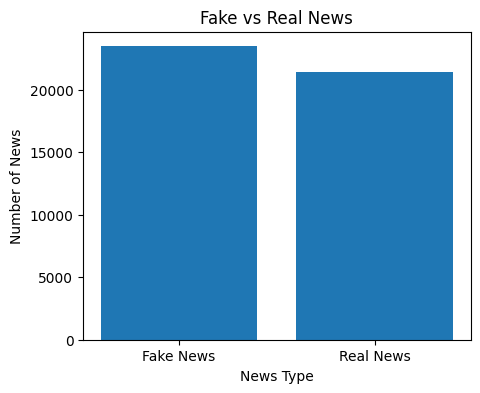

In [16]:
import matplotlib.pyplot as plt

# Count labels
count = news_data["label"].value_counts()

# Create bar chart
plt.figure(figsize=(5,4))
plt.bar(["Fake News", "Real News"], count.values)

plt.title("Fake vs Real News")
plt.xlabel("News Type")
plt.ylabel("Number of News")

plt.show()

In [17]:
import joblib

# Save model
joblib.dump(model, "fake_news_model.pkl")

# Save vectorizer
joblib.dump(vectorizer, "count_vectorizer.pkl")

print("Model saved successfully")

Model saved successfully


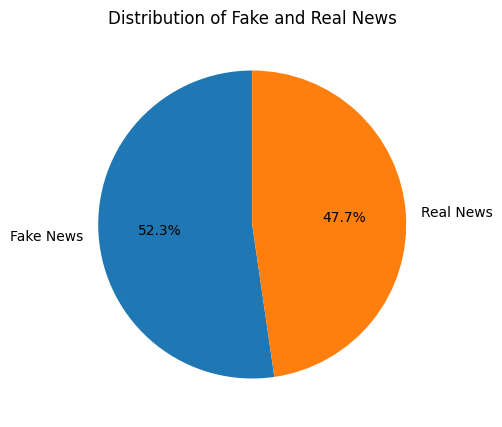

In [18]:
#pie chart
plt.figure(figsize=(5,5))

plt.pie(
    count.values,
    labels=["Fake News", "Real News"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Fake and Real News")

plt.show()

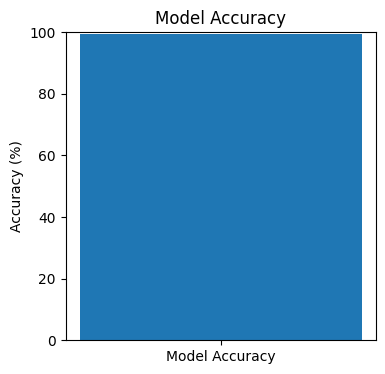

In [19]:
#Accuracy ko graph me dikhana

plt.figure(figsize=(4,4))

plt.bar(["Model Accuracy"], [accuracy*100])

plt.ylim(0,100)

plt.ylabel("Accuracy (%)")

plt.title("Model Accuracy")

plt.show()

In [ ]:
#multiple news prediction
while True:
    news = input("Enter News: ")

    data = vectorizer.transform([news])

    result = model.predict(data)

    if result[0] == 1:
        print("Real News")
    else:
        print("Fake News")

    choice = input("Check another news? (yes/no): ")

    if choice.lower() != "yes":
        break

In [ ]:
# Find the top 10 most common words in the dataset

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

cv = CountVectorizer(stop_words="english", max_features=10)

word_matrix = cv.fit_transform(news_data["text"])

words = cv.get_feature_names_out()

counts = word_matrix.toarray().sum(axis=0)

word_df = pd.DataFrame({
    "Word": words,
    "Count": counts
})

word_df = word_df.sort_values(by="Count", ascending=False)

print(word_df)

In [ ]:
# Display the confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, prediction)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Show dataset distribution

news_data["label"].value_counts().plot(kind="bar")

plt.title("Dataset Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

# Project Objective

The main objective of this project is to identify whether a news article is Fake or Real using Machine Learning.

The project uses CountVectorizer to convert text into numerical data and Logistic Regression for classification.

# Project Conclusion

This project successfully classifies news as Fake or Real using Machine Learning.

CountVectorizer was used to convert text into numerical features, and Logistic Regression was used for classification.

The model achieved an accuracy of 99.48%, showing excellent performance.

# Future Scope

- Improve the model using Deep Learning.
- Build a web application using Flask or Streamlit.
- Add support for multiple languages.
- Use live news data for real-time prediction.

# References

- Scikit-learn Documentation
- Pandas Documentation
- Matplotlib Documentation
- Fake and Real News Dataset

# Fake News Detection Using Machine Learning

### Developed By:
Amit Prajapati

### Branch:
B.Tech – Artificial Intelligence & Machine Learning (AIML)

### Tools Used:
- Python
- Google Colab
- Pandas
- Scikit-learn
- Matplotlib

# Dataset Information

Dataset Name: Fake and Real News Dataset

Source: GitHub

Files Used:
- Fake.csv
- True.csv

The dataset contains fake news articles and real news articles used for training and testing the machine learning model.

# Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Preprocessing
4. Add Labels
5. Merge Dataset
6. Train-Test Split
7. Convert Text using CountVectorizer
8. Train Logistic Regression Model
9. Predict News
10. Evaluate Model
11. Visualize Results